# Lab:  Nonlinear Least Squares for Modeling Materials

In this lab, we will explore gradient descent on nonlinear least squares.  Suppose we wish to fit a model of the form,

     yhat = f(x,w)
     
where `w` is a vector of paramters and `x` is the vector of predictors.  In nonlinear least squares, we find `w` by minimizing a least-squares function 

     J(w) = \sum_i (y_i - f(x_i,w))^2
     
where the summation is over training samples `(x_i,y_i)`.  In general, this optimization has no closed-form expression.  So gradient descent is widely used.  

In this lab, we will implement gradient descent on nonlinear least squares in physical modeling of materials.  Specifically, e we will estimate parameters for expansion of copper as a function of temperature.  In doing this lab, you will learn to:
* Set up a nonlinear least squares as an unconstrained optimization function
* Compute initial parameter estimates for a simple rational model
* Compute the gradients of the least squares objective
* Implement gradient descent for minimizing the objective
* Implement momentum gradient descent
* Visualize the convergence of the algorithm

We first import some key packages.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression

## Load the Data

The NIST agency has an excellent [nonlinear regression website](https://www.itl.nist.gov/div898/strd/nls/nls_main.shtml) that has several datasets for trying nonlinear regression problem.  In this lab, we will use the data from a NIST study involving the thermal expansion of copper. The response variable is the coefficient of thermal expansion, and the predictor variable is temperature in degrees kelvin.  

> Hahn, T., NIST (1979), Copper Thermal Expansion Study.  (unpublished}

You can download the data as follows.  Note that if you directly use the `pd.read_csv(url, ...)` command you will get an HTTP 403 error.  The code below makes it appear as if the request is coming from a browser.

In [68]:


url = 'https://www.itl.nist.gov/div898/handbook/datasets/HAHN1.DAT'


import pandas as pd
import requests
from io import StringIO

# Simulate a browser request
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

# Raise an error if the request failed
response.raise_for_status()

# Read the content into pandas
data = StringIO(response.text)
df = pd.read_csv(data, sep='\s+', header=None, skiprows=25)
df.columns = ["x0", "y0"]

df.head()





,x0,y0
0,24.41,0.591
1,34.82,1.547
2,44.09,2.902
3,45.07,2.894
4,54.98,4.703


Extract the `x0` and `y0` into arrays.  Rescale, `x0` and `y0` to values between `0` and `1` by dividing `x0` and `y0` by the maximum value.  Store the scaled values in vectors `x` and `y`.  The rescaling will help with the conditioning of the fitting.  Plot, `y` vs. `x`. 

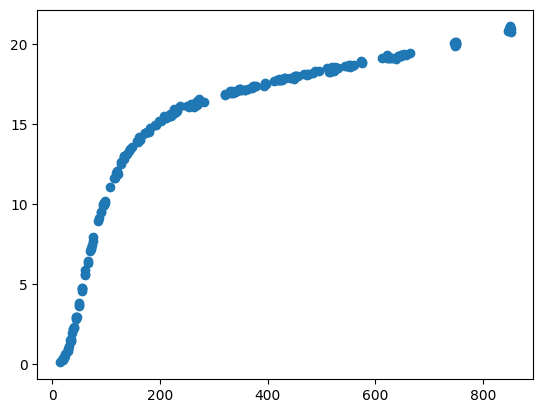

In [69]:
# TODO
x0 = df['x0']
y0 = df['y0']
x = x0/np.max(x0)
y = y0/np.max(y0)
plt.plot(x0,y0,'o')

To make the problem a little more challenging, we will add some noise.  Add random Gaussian noise with mean 0 and std. dev = 0.02 to `y`.  Store the noisy results in `yn`. You can use the `np.random.normal()` function to add Gaussian noise. Plot `yn` vs. `x`.

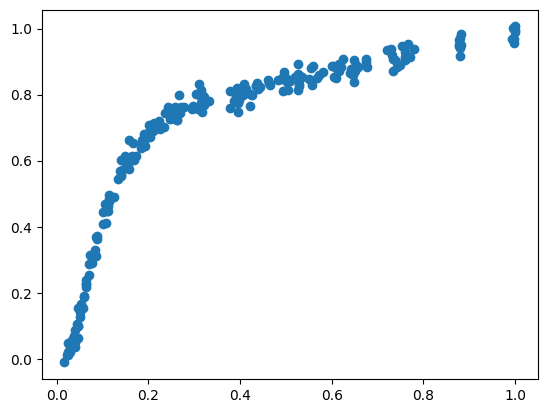

In [70]:
# TODO
yn = y + np.random.normal(loc=0, scale=0.02, size=df.shape[0])
plt.plot(x,yn,'o')

Split the data `(x,yn)` into training and test.  Let `xtr,ytr` be training data and `xts,yts` be the test data.  You can use the `train_test_split` function.  Set `test_size=0.33` so that 1/3 of the samples are held out for test.

In [71]:
from sklearn.model_selection import train_test_split

# TODO
xtr, xts, ytr, yts = train_test_split(x, yn, test_size=0.33)

In [72]:
type(xtr)

pandas.core.series.Series

In [73]:
xtr

187    0.166673
152    0.099987
85     0.621165
195    0.316389
103    0.766301
         ...   
233    0.997816
194    0.311234
149    0.064771
1      0.040887
132    0.437665
Name: x0, Length: 158, dtype: float64

In [74]:
xtr.iloc[0] # by index of pandas series (value of first item, at index 0, of right column in cell output above)

np.float64(0.16667253789880343)

In [75]:
# this cell is intended to print the same value as the output value of the cell above
xtr[187] # by index of original index in X, original indicies shown in left column in output of cell two cells above this cell
# but the index (187 now) is going to be different when train_test_split is ran again

np.float64(0.16667253789880343)

In [76]:
xtr = xtr.to_numpy()
ytr = ytr.to_numpy()
xts = xts.to_numpy()
yts = yts.to_numpy()

In [77]:
xtr[:,None].shape, ytr.shape, xts.shape, yts.shape

((158, 1), (158,), (78,), (78,))

In [78]:
def predict(w,x):

    # Get the length
    d = (len(w)-1)//2

    # TODO.  Extract a and b from w
    a = w[:d+1]
    b = w[d+1:]

    # TODO.  Compute yhat.  You may use the np.polyval function
    # But, remember you must flip the order the a and b
    yhat = (a[0] + np.sum(a[1:] * x[:,None]**np.arange(1,d+1), axis=1))/(1 + np.sum(b * x[:,None]**np.arange(1,d+1), axis=1))
    return yhat

When we fit with a nonlinear model, most methods only get convergence to a local minima.  So, you need a good initial condition.  For a rational model, one way to get is to realize that if:


    y ~= (a[0] + a[1]*x + ... + a[d]*x^d)/(1 + b[0]*x + ... + b[d-1]*x^d)
    
Then:

    y ~= a[0] + a[1]*x + ... + a[d]*x^d - b[0]*x*y + ... - b[d-1]*x^d*y.
    
So, we can solve for the the parameters `w = [a,b]` from linear regression of the predictors,

    Z[i,:] = [ x[i], ... , x[i]**d, y[i]*x[i], ... , y[i}*x[i]**d ] 

In [79]:
d = 3

# TODO.  Create the transformed feature matrix
XZ = xtr[:,None]**np.arange(1,d+1)
Z = np.hstack((XZ, XZ * ytr[:,None]))

# TODO.  Fit with parameters with linear regression
regr = LinearRegression(fit_intercept=True)
regr.fit(Z,ytr)

# TODO
# Extract the parameters from regr.coef_ and regr.intercept_ and store the parameter vector in winit
a_0 = regr.intercept_
a_coef = regr.coef_[0:d]
b_coef = -regr.coef_[d:]
winit = np.hstack((a_0, a_coef, b_coef))

In [80]:
Z.shape

(158, 6)

In [82]:
winit

array([ -0.24562854,  10.91956006, -38.87450904,  31.45925634,
         4.86149869, -30.40689775,  27.87440076])

In [83]:
regr.coef_

array([ 10.91956006, -38.87450904,  31.45925634,  -4.86149869,
        30.40689775, -27.87440076])

Now plot the predicted values of the `yhat` vs. `x` using your estimated parameter `winit` for 1000 values `x` in `[0,1]`.  On the same plot, plot `yts` vs. `xts`.  You will see that you get a horrible fit.

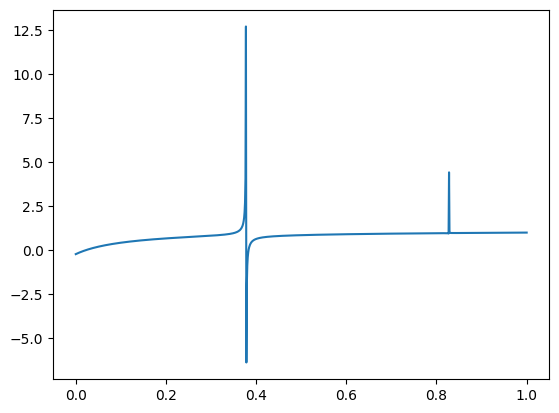

In [84]:
# TODO
xp = np.linspace(0,1,1000)
yhat = predict(winit, xp)
plt.plot(xp,yhat)

The reason the previous fit is poor is that the denominator in `yhat` goes close to zero.   To avoid this problem, we can use Ridge regression, to try to keep the parameters close to zero.  Re-run the fit above with `Ridge` with `alpha = 1e-2`. You should see you get a reasonable, but not perfect fit.

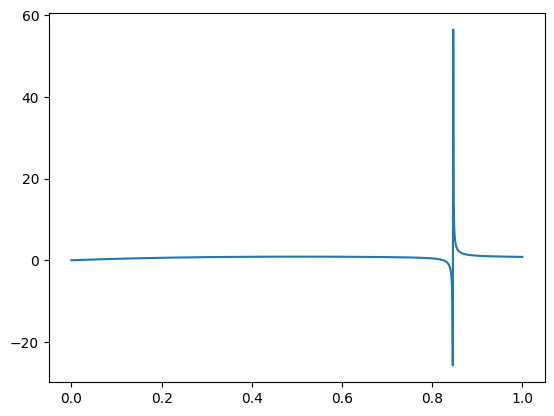

In [85]:
# TODO.  Fit with parameters with linear regression
regr = Ridge(alpha=1e-3)
regr.fit(Z, ytr)

# TODO
# Extract the parameters from regr.coef_ and regr.intercept_
a_0 = regr.intercept_
a_coef = regr.coef_[0:d]
b_coef = -regr.coef_[d:]
winit = np.hstack((a_0, a_coef, b_coef))

# TODO
# Plot the results as above.
yhat = predict(winit, xp)
plt.plot(xp,yhat)

In [86]:
winit

array([ 0.01146627,  4.00047604, -6.93574259,  2.50917483, -0.48617571,
        0.24661862, -1.2613626 ])

In [87]:
winit.shape

(7,)

In [88]:
xtr.shape, ytr.shape, xts.shape, yts.shape

((158,), (158,), (78,), (78,))

In [89]:
len(xtr)

158

## Creating a Loss Function

We can now use gradient descent to improve our initial estimate.  Complete the following function to compute

    f(w) = 0.5*\sum_i (y[i] - yhat[i])^2
    
and `fgrad`, the gradient of `f(w)`.

In [90]:
def feval(w,x,y):
        
    
    # TODO.  Parse 
    d = (len(w) - 1)//2
    a = w[:d+1]
    b = w[d+1:]
    
    n = len(x)

    # TODO.  Znum[i,j] = x[i]**j
    Znum = np.hstack (( a[0]*np.ones((n,1)).reshape(-1,1) , a[1:]*x[:,None]**np.arange(1,d+1) )) # shape(n,d+1)

    # TODO.  Zden[i,j] = x[i]**(j+1)
    Zden = np.hstack(( np.ones((n,1)).reshape(-1,1) , b*x[:,None]**np.arange(1,d+1) )) # shape(n,d)
    
    # TODO.  Compute yhat 
    # Compute the numerator and denominator
    Num = np.sum(Znum, axis=1) # shape (n,)
    Den = np.sum(Zden, axis=1) # shape (n,)
    yhat = Num / Den 
    
    # TODO.  Compute loss
    f = 0.5 * np.sum((y - yhat)**2)
    
    # TODO.  Compute gradients
    dyhat_da = x[:, None]**np.arange(d+1) / Den[:,None] # shape (n,d+1)
    dyhat_db = -(Num[:,None]/Den[:,None]**2)*(x[:,None]**np.arange(1,d+1)) # shape (n,d)

    yerr = (y - yhat)[:,None] # y error, shape (n,1)

    df_da = np.sum(yerr*(-dyhat_da), axis=0) # shape (d+1,)
    df_db = np.sum(yerr*(-dyhat_db), axis=0) # shape (d,)

    fgrad = np.hstack((df_da, df_db)) # shape (2d+1,)
    
    return f, fgrad


Test the gradient function:
* Take `w0=winit` and compute `f0,fgrad0 = feval(w0,xtr,ytr)`
* Take `w1` very close to `w0` and compute `f1,fgrad1 = feval(w1,xtr,ytr)`
* Verify that `f1-f0` is close to the predicted value based on the gradient.

In [91]:
# TODO
w0 = winit
f0, fgrad0 = feval(w0, xtr, ytr)

step = 1e-5
w1 = w0 + step*np.random.randn(len(w0))

f1, fgrad1 = feval(w1, xtr, ytr)

In [92]:
# Predict the amount the function should have changed based on the gradient
df_est = fgrad0.dot(w1-w0)

# Print the two values to see if they are close
print("Actual f1-f0    = %12.4e" % (f1-f0))
print("Predicted f1-f0 = %12.4e" % df_est)

Actual f1-f0    =  -6.8925e-04
Predicted f1-f0 =  -6.8952e-04


## Implement gradient descent

We will now try to minimize the loss function with gradient descent.  Using the function `feval` defined above, implement gradient descent.  Run gradient descent with a step size of `alpha=1e-6` starting at `w=winit`.  Run it for `nit=10000` iterations.  Compute `fgd[it]`= the objective function on iteration `it`.  Plot `fgd[it]` vs. `it`.  

You should see that the training loss decreases, but it still hasn't converged after 10000 iterations.

In [93]:
nit = 10000
step = 1e-6 # alpha
w = winit
fgd = np.zeros((nit))

for it in range(nit):
    # Evaluate the function and gradient
    f0, fgrad0 = feval(w0, xtr, ytr)

    # gradient step:
    w0 = w0 - step*fgrad0

    fgd[it] = f0

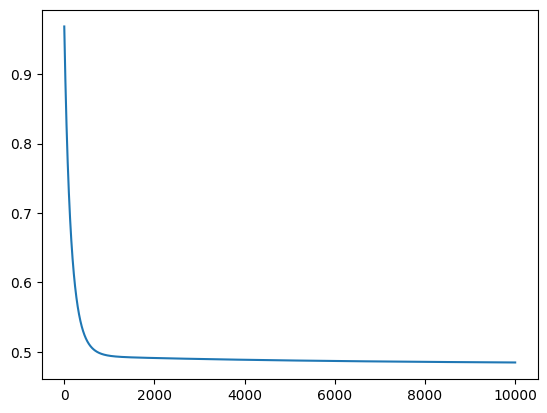

In [94]:
plt.plot(np.arange(nit), fgd)

Now, try to get a faster convergence with adaptive step-size using the Armijo rule. Implement the gradient descent with adaptive step size.  Let `fadapt[it]` be the loss function on iteration `it`.  Plot `fadapt[it]` and `fgd[it]` vs. `it` on the same graph.  You should see a slight improvement, but not much.

In [ ]:
nit = 10000
step = 1e-6  # Initial step
step_min = 1e-6

w0 = winit
f0, fgrad0 = feval(w0,xtr,ytr)

fgdadpt = np.zeros((nit))

for it in range(nit):
    # Take a gradient step
    w1 = w0 - step*fgrad0 # compute next gradient step using previous gradient fgrad0. This gradient step is now the current step

    # Evaluate the test point by computing the objective function, f1,
    # at the test point and the predicted decrease, df_est
    f1, fgrad1 = feval(w1, xtr, ytr) # compute the function value and gradient of current step, f1 and fgrad1 respectively
    df_est = fgrad0.dot(w1-w0) # compute the estimated amount of decent using the previous gradient. What the predicted amount of descent would have been based on gradient from before (fgrad0)

    # Check if test point passes the Armijo condition
    alpha = 0.5
    if (f1-f0 < alpha*df_est) and (f1 < f0): # if current descent, f1-f0, is less than what predicted amount of descent from previous step was
        # If descent is sufficient, accept the point and increase the
        # learning rate
        step = step*2 # increase learning rate (i.e. step size). The more descent the better
        f0 = f1
        fgrad0 = fgrad1
        w0 = w1
    else: # if we either increased current function value (f1 - f0 >= 0) or we are not getting as much descent as what we predicted we would have gotten
        # Otherwise, decrease the learning rate
        step = step/2 # take smaller steps
        step = np.maximum(step, step_min) # but not smaller than the smallest step we want to take
    
    # Basically, if we are doing it right (more descent than predicted), take bigger steps, else take smaller steps

    fgdadpt[it] = f0
    
    

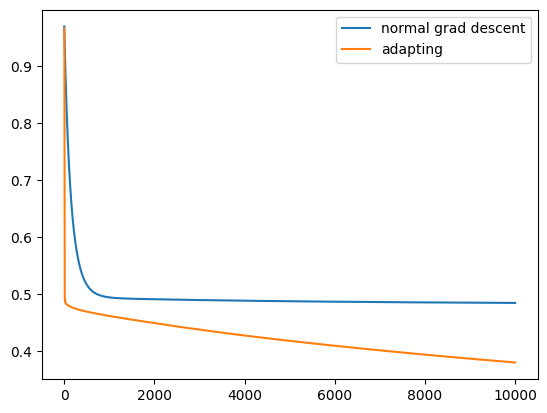

In [96]:
plt.plot(np.arange(nit), fgd)
plt.plot(np.arange(nit), fgdadpt)

plt.legend(['normal grad descent','adapting'])

Using he final estimate for `w` from the adaptive step-size plot the predicted values of the `yhat` vs. `x` usfor 1000 values `x` in `[0,1]`.  On the same plot, plot `yhat` vs. `x` for the initial parameter `w=winit`.  Also, plot `yts` vs. `xts`.  You should see that gradient descent was able to improve the estimat slightly, although the initial estimate was not too bad.

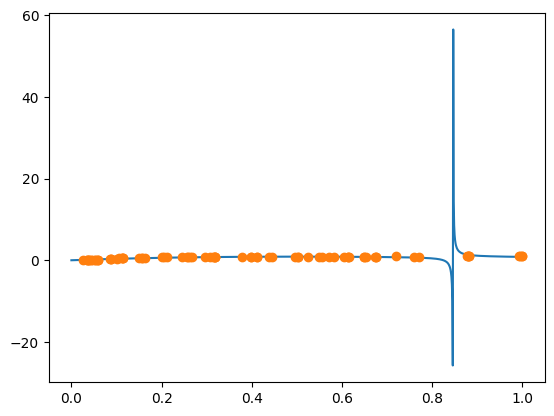

In [97]:
# TODO
xp = np.linspace(0,1,1000)
yhat = predict(winit, xp)
plt.plot(xp,yhat)
plt.plot(xts,yts,'o')

## Momentum Gradient Descent

This section is bonus.  You will get up to +2 out of 20 points for this.

One way to improve gradient descent is to use *momentum*.  In momentum gradient descent, the update rule is:

    f, fgrad = feval(w,...)
    z = beta*z + fgrad
    w = w - step*z
    
This is similar to gradient descent, except that there is a second order term on the gradient.  Implement this algorithm with `beta = 0.99` and `step=1e-3`.   Compare the convergence of the loss function with gradient descent.  

In [98]:
# TODO
nit = 1000
step = 1e-3
beta = 0.99



for it in range(nit):
    print(it)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
# TODO:  Plot the yhat vs xp for momentum method